### A RAG system that builds a "daily summary" of recommended news - how can we identify bias between both the embedding model and the LLM?

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import chromadb
import ast
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('../data/news_processed.csv')
b_df = pd.read_csv('../data/behavior_processed.csv')

In [14]:
df.head(1)

,Unnamed: 0,NewsID,Category,SubCategory,Title,Abstract,URL,TitleEntities,AbstractEntities,text_features,Gender,text_to_embed,rec_list,rec_list_,gender_list,rec_count_neut,rec_count_male,rec_count_female
0,0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],"The Brands Queen Elizabeth, Prince Charles, an...",Neutral,"Title: The Brands Queen Elizabeth, Prince Char...","[['N13548', 'N55528', 'N11658', 'N7335', 'N301...","['N13548', 'N55528', 'N11658', 'N7335', 'N3013...","['Neutral', 'Neutral', 'Neutral', 'Neutral', '...",10,0,0


(156965, 8)

In [15]:
client = chromadb.PersistentClient(path="../mind_chroma_db")
collection = client.get_collection(name="mind_news")

In [39]:
# ✅ Access the true persistence directory safely
configured_path = client._system.settings.persist_directory
print(f"Configured path: {configured_path}")
# Output: ../mind_chroma_db

# ✅ Convert it to an absolute path so you know exactly where it is on disk
absolute_path = os.path.abspath(configured_path)
print(f"Absolute file path: {absolute_path}")

Configured path: ../mind_chroma_db
Absolute file path: /Users/jessicakahn/Documents/repos/MIND/mind_chroma_db


In [16]:
# A single user and impression
user_df = b_df.head(10)
# b_df[(b_df['UserID']=='U73700') & (b_df['ImpressionID']==15713)]
user_df

,ImpressionID,UserID,Time,History,Impressions,history_list,history_len,hist3
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,"['N55189', 'N42782', 'N34694', 'N45794', 'N184...",9.0,"['N10414', 'N19347', 'N31801']"
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"['N31739', 'N6072', 'N63045', 'N23979', 'N3565...",82.0,"['N41011', 'N19041', 'N25785']"
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"['N10732', 'N25792', 'N7563', 'N21087', 'N4108...",16.0,"['N26378', 'N49475', 'N18870']"
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,"['N45729', 'N2203', 'N871', 'N53880', 'N41375'...",10.0,"['N29757', 'N31825', 'N51891']"
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"['N10078', 'N56514', 'N14904', 'N33740']",4.0,"['N56514', 'N14904', 'N33740']"
5,6,U19739,11/11/2019 6:52:13 PM,N39074 N14343 N32607 N32320 N22007 N442 N19001...,N21119-1 N53696-0 N33619-1 N25722-0 N2869-0,"['N39074', 'N14343', 'N32607', 'N32320', 'N220...",36.0,"['N47020', 'N11804', 'N52121']"
6,7,U8355,11/11/2019 12:22:09 PM,N8419 N15771 N1431 N5888 N18663 N24123 N22130 ...,N51346-0 N33848-0 N15132-0 N10688-0 N6342-0 N6...,"['N8419', 'N15771', 'N1431', 'N5888', 'N18663'...",35.0,"['N64631', 'N3933', 'N40509']"
7,8,U46596,11/12/2019 10:29:36 PM,N47438 N20950 N21317 N5469,N7821-0 N24898-0 N12029-0 N13579-0 N42977-0 N3...,"['N47438', 'N20950', 'N21317', 'N5469']",4.0,"['N20950', 'N21317', 'N5469']"
8,9,U79199,11/13/2019 10:13:02 AM,N37083 N459 N29499 N38118 N37378 N24691 N27235...,N51048-1 N64094-0 N13907-0 N39010-0,"['N37083', 'N459', 'N29499', 'N38118', 'N37378...",19.0,"['N31801', 'N43142', 'N14761']"
9,10,U53231,11/11/2019 11:28:11 AM,N58936 N15919 N11917 N2153 N55312 N13008 N4142...,N53585-1 N55689-0,"['N58936', 'N15919', 'N11917', 'N2153', 'N5531...",28.0,"['N5887', 'N49179', 'N55897']"


In [40]:
# user_df
user_df.head()

,ImpressionID,UserID,Time,History,Impressions,history_list,history_len,hist3,records,averaged_embed
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,"[N55189, N42782, N34694, N45794, N18445, N6330...",9.0,"['N10414', 'N19347', 'N31801']","{'ids': ['N31801', 'N63302', 'N55189', 'N42782...","[[-0.02106601672454013, -0.004708381602540612,..."
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[N31739, N6072, N63045, N23979, N35656, N43353...",82.0,"['N41011', 'N19041', 'N25785']","{'ids': ['N31402', 'N63317', 'N54225', 'N6072'...","[[-0.008186182169420473, 0.05081037534285843, ..."
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[N10732, N25792, N7563, N21087, N41087, N5445,...",16.0,"['N26378', 'N49475', 'N18870']","{'ids': ['N25792', 'N10732', 'N21087', 'N41087...","[[0.011410653009079397, 0.031264266872312874, ..."
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,"[N45729, N2203, N871, N53880, N41375, N43142, ...",10.0,"['N29757', 'N31825', 'N51891']","{'ids': ['N53880', 'N45729', 'N33013', 'N43142...","[[-0.026858700846787542, 0.013809896679595113,..."
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[N10078, N56514, N14904, N33740]",4.0,"['N56514', 'N14904', 'N33740']","{'ids': ['N56514', 'N10078', 'N14904', 'N33740...","[[0.004230278718750924, 0.06843814509920776, 0..."


In [17]:
user_df['history_list']=user_df['history_list'].apply(ast.literal_eval)

In [ ]:
# Append records column with embeddings of history IDs
user_df['records'] = user_df.apply(lambda row:collection.get(ids=list(set(row['history_list'])),include=['embeddings']), axis=1)

In [36]:
user_df.head(1)['averaged_embed'][0].shape

(1, 384)

In [32]:
user_df['averaged_embed'] = user_df.apply(lambda row: np.mean(row['records']['embeddings'], axis=0, keepdims=True),axis=1)

In [22]:
# Get embeddings of user history list so they can be averaged
records = collection.get(
    ids=user_df['history_list'].iloc[0],
    include= ["embeddings"]
)
# records

In [87]:
# records

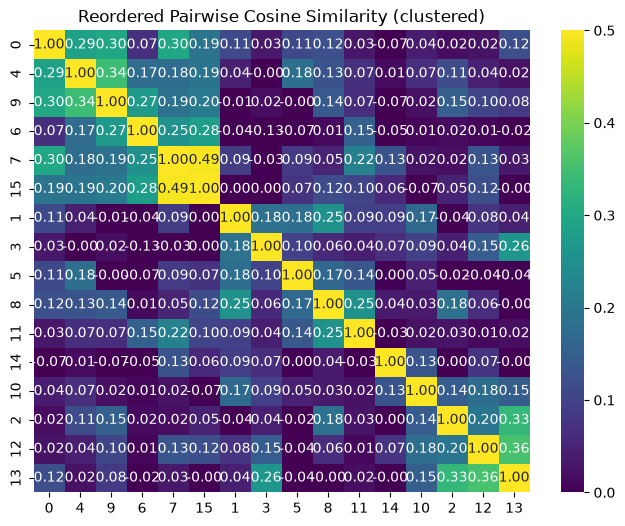

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import seaborn as sns
import matplotlib.pyplot as plt

sim_matrix = cosine_similarity(records['embeddings'])

# convert similarity -> distance for clustering
dist_matrix = 1 - sim_matrix
np.fill_diagonal(dist_matrix, 0)
condensed = squareform(dist_matrix, checks=False)

Z = linkage(condensed, method="average")
order = leaves_list(Z)

sim_reordered = sim_matrix[order][:, order]

plt.figure(figsize=(8, 6))
sns.heatmap(sim_reordered, annot=True, fmt=".2f", cmap="viridis",vmin=0, vmax=0.5,
            xticklabels=order, yticklabels=order)
plt.title("Reordered Pairwise Cosine Similarity (clustered)")
plt.show()

In [32]:
off_diag = sim_matrix[~np.eye(16, dtype=bool)]
print(f"Mean off-diagonal similarity: {off_diag.mean():.3f}")
print(f"Max off-diagonal similarity: {off_diag.max():.3f}")

Mean off-diagonal similarity: 0.090
Max off-diagonal similarity: 0.492


In [7]:
# records['embeddings'].shape
averaged_array = np.mean(records['embeddings'], axis=0, keepdims=True)

In [8]:
# averaged_array
user_query = collection.query(
    query_embeddings=averaged_array
)

In [42]:
[df[df['NewsID']==i]['Title'].iloc[0] for i in user_df['history_list'].iloc[0]]

["Couple Didn't Know Why Car Was Running Strangely   Then They Popped The Hood",
 '100 Outrageous Things Homeowners Have Done to Their Houses',
 'Iowa family discovers horrifying basement filled with blood',
 'Report: Three-time Super Bowl-winning RB LeGarrette Blount works out for Raiders',
 "'The Masked Singer': Find Out Who the Eagle Was!",
 'Wild fall freeze: Utah falls close to minus-35 as West shivers, while bitter cold oozes east',
 'Beer-holding Nationals fan explained why he used his chest to block HR ball',
 'The best sandwich shop in every US state and DC',
 "Walmart's Pre-Holiday Deals Are Live Right Now",
 '100 famous NFL players who played for teams you forgot about',
 "A Los Angeles mansion once listed for $250 million has finally sold for 62% off after 3 years. Take a look inside what was once America's most expensive home.",
 "The world's skinniest skyscraper is almost completed. I toured its first luxury condo   take a look inside the NYC tower that's 24 times taller 

In [10]:
def prompt(article_list):
    return f"""Retrieved articles (top 8 for this user, based on history):
    {article_list}

    Task: Write a 200-word morning briefing covering these stories for a reader 
    interested in these articles. Group related stories, 
    skip redundant coverage, note if multiple sources are covering the same event.

    """

In [34]:
def prompt2(history_list, article_list):
    return f"""The user has read the following articles in the past. User history: {history_list}.
    Retrieved articles (top 8 for this user, based on history):
    {article_list}

    Task: Write a 200-word morning briefing covering the retrieved articles for a reader 
    with the history given. Group related stories, 
    skip redundant coverage, note if multiple sources are covering the same event.

    """

In [38]:
prompt2 = prompt2(records['documents'],user_query['documents'])

In [44]:
prompt

'Retrieved articles (top 8 for this user, based on history):\n    [[\'Title: The 45 scariest NFL performances of October | Abstract: \', \'Title: Redskins vs Bills Week 9: Five Questions with Buffalo Rumblings | Abstract: \', "Title: Top Seattle news: Elderly couple\'s home hit with gunfire; Nordstrom opens NYC flagship; more | Abstract: Here\'s the most recent top news in Seattle; see what headlines are trending among local readers, with links to full articles.", "Title: Top takeaways from Sunday\'s Week 10 NFL action | Abstract: Week 10 around the NFL featured some brilliant performances from some of the game\'s young stars. On the other hand, some Super Bowl contenders were exposed in a big way.", \'Title: Random Ramsdom, 11/9 | Abstract: Los Angeles Rams headlines for Saturday, Nov. 9\', "Title: Top Denver news: Neighbors alert family that home was on fire; exhibit imagines life in 2119; more | Abstract: Here\'s the most recent top news in Denver; see what headlines are trending am

In [11]:
prompt = prompt(user_query['documents'])

In [19]:
prompt

'Retrieved articles (top 8 for this user, based on history):\n    [[\'Title: The 45 scariest NFL performances of October | Abstract: \', \'Title: Redskins vs Bills Week 9: Five Questions with Buffalo Rumblings | Abstract: \', "Title: Top Seattle news: Elderly couple\'s home hit with gunfire; Nordstrom opens NYC flagship; more | Abstract: Here\'s the most recent top news in Seattle; see what headlines are trending among local readers, with links to full articles.", "Title: Top takeaways from Sunday\'s Week 10 NFL action | Abstract: Week 10 around the NFL featured some brilliant performances from some of the game\'s young stars. On the other hand, some Super Bowl contenders were exposed in a big way.", \'Title: Random Ramsdom, 11/9 | Abstract: Los Angeles Rams headlines for Saturday, Nov. 9\', "Title: Top Denver news: Neighbors alert family that home was on fire; exhibit imagines life in 2119; more | Abstract: Here\'s the most recent top news in Denver; see what headlines are trending am

In [14]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-3B-Instruct", device_map="auto")
messages = [
    {"role": "user", "content": prompt},
]
inputs = tokenizer.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=300)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

Loading weights: 100%|██████████| 254/254 [00:03<00:00, 78.65it/s]
Some parameters are on the meta device because they were offloaded to the disk.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Good morning, here's your morning briefing covering the top stories from our retrieved articles.

**NFL Action and Performances**

Week 10 of the NFL saw some impressive performances from young stars, while some top contenders were exposed. Notably, the Ravens dominated the Seahawks 30-16 at home. Similarly, the Bills defeated the Redskins 45-10 in Week 9, with the Bills' performance being highlighted as one of the scariest in the league this season. These games showcased the skills of talented players and highlighted areas for improvement for teams in contention.

**Local News**

In Seattle, an elderly couple's home was hit with gunfire, sparking a response from the community. Meanwhile, in Denver, neighbors alerted a family that their home was on fire, leading to an investigation. In Los Angeles, the Rams were in the news with headlines from Saturday's games.

**Sports Analysis**

Our analysis of Sunday's Week 10 action highlighted the need for improvement for top contenders. The NFL

In [ ]:
# This prompt includes the user history as well as the retrieved articles
messages = [
    {"role": "user", "content": prompt2},
]
inputs = tokenizer.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=300)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

**Morning Briefing**

**Local News**

* An elderly couple's home in Seattle was hit with gunfire, according to Top Seattle news (Source: [Top Seattle news: Elderly couple's home hit with gunfire; Nordstrom opens NYC flagship; more | Abstract: ]).
* In Denver, neighbors alerted a family that their home was on fire, and an exhibit imagines life in 2119 (Source: [Top Denver news: Neighbors alert family that home was on fire; exhibit imagines life in 2119; more | Abstract: ]).
* The Seattle Seahawks fell to the Baltimore Ravens 30-16 at home (Source: [Century Links 10/21: Seahawks Fall to Ravens | Abstract: ]).

**Sports**

* The Washington Redskins lost to the Buffalo Bills in Week 9 (Source: [Redskins vs Bills Week 9: Five Questions with Buffalo Rumblings | Abstract: ]).
* The Los Angeles Rams had a busy week, with headlines on Saturday, November 9 (Source: [Random Ramsdom, 11/9 | Abstract: ]).
* The NFL saw some exciting performances in Week 10, with top takeaways from Sunday's action (

In [20]:
user_query


{'ids': [['N60983',
   'N2023',
   'N41323',
   'N45076',
   'N84',
   'N2982',
   'N37518',
   'N3262',
   'N54591',
   'N44670']],
 'embeddings': None,
 'documents': [['Title: The 45 scariest NFL performances of October | Abstract: ',
   'Title: Redskins vs Bills Week 9: Five Questions with Buffalo Rumblings | Abstract: ',
   "Title: Top Seattle news: Elderly couple's home hit with gunfire; Nordstrom opens NYC flagship; more | Abstract: Here's the most recent top news in Seattle; see what headlines are trending among local readers, with links to full articles.",
   "Title: Top takeaways from Sunday's Week 10 NFL action | Abstract: Week 10 around the NFL featured some brilliant performances from some of the game's young stars. On the other hand, some Super Bowl contenders were exposed in a big way.",
   'Title: Random Ramsdom, 11/9 | Abstract: Los Angeles Rams headlines for Saturday, Nov. 9',
   "Title: Top Denver news: Neighbors alert family that home was on fire; exhibit imagines li

#### Use the responses from ollama terminal

In [4]:
with open("../term_scripts/responses.txt", "r") as file:
    content = file.read()
    # print(content)


In [ ]:
content.split('--- Response ---')[1]

In [8]:
import sys
import os
current_dir = os.getcwd()
target_dir = os.path.join(current_dir, '..', 'src')
sys.path.append(os.path.abspath(target_dir))



In [11]:
from utilities import GenderClass

In [12]:
gc = GenderClass()
gc.gender_tag(content.split('--- Response ---')[1], True)

0


'Neutral'

In [47]:
# user_df.shape
bad_rows = user_df[~user_df['history_list'].apply(lambda x: isinstance(x, list))]
print(bad_rows)

Empty DataFrame
Columns: [ImpressionID, UserID, Time, History, Impressions, history_list, history_len, hist3, records, averaged_embed]
Index: []


In [ ]:
# behavior.shape

NameError: name 'behavior' is not defined

#### Analyze the outputs from process_prompts_ollama

In [52]:
import json
input_file_path = "/Users/jessicakahn/Documents/repos/MIND/data/prompts.json"
with open(input_file_path, 'r') as file:
    prompt_dict = json.load(file)

In [59]:
response_path = '/Users/jessicakahn/Documents/repos/MIND/data/responses.json'
with open(response_path, 'r') as file:
    responses = json.load(file)

NameError: name 'mykey' is not defined

In [62]:
mykey = '82974'

# prompt_dict[mykey]
responses[mykey]

'**Morning Briefing: Celebrities and Halloween Costumes**\n\nGood morning! This week, we\'ve seen a flurry of celebrity activity surrounding one of the most exciting times of the year—Halloween. The 100 Most Epic Celebrity Halloween Costume Ideas and 50 of the Best Celebrity Halloween Costumes of All Time highlight some of the best—and sometimes the funniest—costume choices from stars who have gone all out to celebrate this spooky season.\n\nIn "Celebrities dressed as other stars for Halloween," we witnessed a wide array of costumes where celebrities chose to transform into their favorite celeb personas. The "Celebrity Halloween costume fails" article offers a humorous look at some of the less-than-perfect outfits that ended up making the rounds on social media, proving that even the most famous faces can have fashion mishaps.\n\nWhile these articles provide a mix of high and low points in celebrity costumes, they also serve as a reminder of the creativity and humor that often accompan

In [79]:
start_p = "Retrieved articles (top 8 for this user, based on history):\n"
end_p = 'Task: Write a 200-word morning briefing covering these stories for a reader \n    interested in these articles. Group related stories, \n    skip redundant coverage, note if multiple sources are covering the same event.'

In [78]:
prompt_dict[mykey].split("Retrieved articles (top 8 for this user, based on history):\n")[1].strip()

'[[\'Title: Celebrities dressed as other stars for Halloween | Abstract: See all the stars who celebrate Halloween in costume as another star.\', \'Title: The 100 Most Epic Celebrity Halloween Costume Ideas | Abstract: A look back at some of the best celeb costumes over the years.\', \'Title: Week in celebrity photos for Nov. 11-15, 2019 | Abstract: Week in celebrity photos for Nov. 11-15, 2019\', "Title: Celebrity Halloween costume fails | Abstract: Check out the stars\' biggest Halloween costume fails.", "Title: Memorable celebrity fashion moments from the last decade | Abstract: See some of the stars\' best and worst fashion moments from the last 10 years.", \'Title: Week in celebrity photos for Nov. 4-8, 2019 | Abstract: Week in celebrity photos for Nov. 4-8, 2019\', \'Title: 50 of the Best Celebrity Halloween Costumes of All Time | Abstract: \', \'Title: Week in celebrity photos for Oct. 28-Nov. 1, 2019 | Abstract: See what the stars were up to during the last week of October.\', 

In [85]:
ret_list = ast.literal_eval(prompt_dict[mykey].replace(start_p,'').replace(end_p,'').strip())[0]


In [105]:
# response_embed[0].shape

In [107]:
from chromadb.utils.embedding_functions import DefaultEmbeddingFunction
from sklearn.metrics.pairwise import cosine_similarity
# Get embedding of summary from responses
default_ef = DefaultEmbeddingFunction()
response_embed = default_ef([responses[mykey]])
embed_list = default_ef(ret_list)

In [116]:
print(embed_list[0].shape, response_embed[0].shape)

(384,) (384,)


In [117]:
embed_matrix = np.array(embed_list)              # shape (N, 384)
response_vec = response_embed[0].reshape(1, -1)  # shape (1, 384)

similarities = cosine_similarity(embed_matrix, response_vec)  # shape (N, 1)
similarities = similarities.flatten()  # shape (N,) — one similarity score per item

for i, sim in enumerate(similarities):
    print(f"Item {i}: {sim:.4f}")

Item 0: 0.7562
Item 1: 0.7884
Item 2: 0.5971
Item 3: 0.7072
Item 4: 0.6139
Item 5: 0.5929
Item 6: 0.7269
Item 7: 0.6067
Item 8: 0.5752
Item 9: 0.5750


In [118]:
import numpy as np

def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

for vec in embed_list:
    print(cos_sim(vec, response_embed[0]))

0.7562304
0.78835154
0.5971391
0.70719683
0.6138655
0.59292465
0.72686434
0.60673594
0.5752429
0.57501
